---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 2"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 12. Перехідні процеси другого порядку</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Перехідні процеси другого порядку</li>
  <li>Розрахунок послідовного включення RLC</li>
  <li>Розрахунок паралельного включення RLC</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 12 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Перехідні процеси другого порядку](#commutation-calculation-2nd-order)
    * [Розрахунок послідовного включення RLC](#RLC-series-commutation-calculation-classic)
    * [Розрахунок паралельного включення RLC](#RLC-parallel-commutation-calculation-classic)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
import sympy as sp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---

## Перехідні процеси другого порядку  <a class="anchor" id="commutation-calculation-2nd-order"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Складати диференціальне рівняння для RLC ланцюга
> - Визначати характеристичне рівняння та його корені
> - Розрізняти аперіодичний, критичний та коливальний режими
> - Розраховувати повне рішення для кожного режиму

</div>

### Класифікація режимів RLC ланцюга

| Умова | Режим | Характер перехідного процесу |
|-------|-------|------------------------------|
| $\left(\frac{R}{2L}\right)^2 > \frac{1}{LC}$ | Аперіодичний | Без коливань, експоненціальне загасання |
| $\left(\frac{R}{2L}\right)^2 = \frac{1}{LC}$ | Критичний | Граничний випадок, швидке загасання |
| $\left(\frac{R}{2L}\right)^2 < \frac{1}{LC}$ | Коливальний | Згасаючі коливання з частотою $\omega_d$ |

**Власна частота:** $\omega_0 = \dfrac{1}{\sqrt{LC}}$, &nbsp; **Коефіцієнт загасання:** $\alpha = \dfrac{R}{2L}$



Схема послідовного RLC-кола, яке ключем K вмикається на джерело напруги:

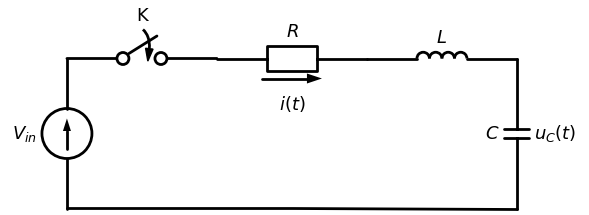

In [2]:
# Schemdraw: послідовне RLC-коло з ключем K
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        v = d.add(EMF().up().label('$V_{in}$'))
        d.add(elm.Switch(action='close').right().label('K'))
        R = d.add(elm.Resistor().right().label('$R$'))
        d.add(elm.CurrentLabel(top=False, length=1.2).at(R).label('$i(t)$'))
        d.add(elm.Inductor().right().label('$L$'))
        c = d.add(elm.Capacitor().down().label('$C$', loc='top').label('$u_C(t)$', loc='bottom'))
        d.add(elm.Line().left().tox(v.start))
else:
    print('pip install schemdraw')

### Розрахунок послідовного включення RLC  <a class="anchor" id="RLC-series-commutation-calculation-classic"></a>

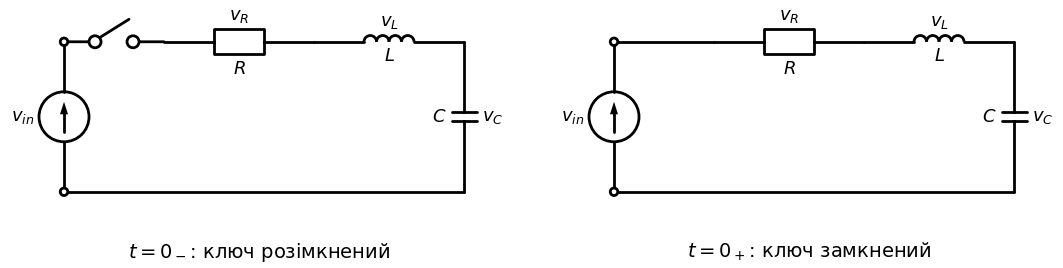

In [3]:
# Схема: послідовне RLC-коло до (t = 0−) і після (t = 0+) комутації
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        for x0, closed, caption in [(0, False, '$t = 0_-$: ключ розімкнений'), (11, True, '$t = 0_+$: ключ замкнений')]:
            src = d.add(EMF().at((x0, 0)).up().label('$v_{in}$'))
            d.add(elm.Dot(open=True).at(src.end))
            d.add(elm.Line().right(2) if closed else elm.Switch().right(2))
            d.add(elm.Resistor().right(3).label('$v_R$').label('$R$', loc='bottom'))
            d.add(elm.Inductor().right(3).label('$v_L$').label('$L$', loc='bottom'))
            d.add(elm.Capacitor().down().label('$C$', loc='top').label('$v_C$', loc='bottom'))
            d.add(elm.Line().left().tox(src.start))
            d.add(elm.Dot(open=True).at(src.start))
            d.add(elm.Label().at((x0 + 4, -1.1)).label(caption, fontsize=14))

Запишемо диференційне рівняння для опису схеми в момент $t(0_+)$ після комутації:

$$v_{in}(t) = v_{R}(t) + v_{L}(t) + v_{C}(t)$$

Струм в контурі:

$$i = i_{c} = C \cdot \cfrac{dv_{c}}{dt}$$

Опишемо напруги на компонентах через напругу на конденсаторі:

$$v_{r} = i \cdot R = RC \cdot \cfrac{dv_{c}}{dt}$$

$$v_{L} = L \cdot \cfrac{di}{dt} = LC \cfrac{d^{2}v_{c}}{dt^{2}}$$

$$ LC \cfrac{d^{2}v_{c}(t)}{dt^{2}} + RC \cdot \cfrac{dv_{c(t)}}{dt} + v_{c}(t) = v_{in}(t)$$

$$ \cfrac{d^{2}v_{c}(t)}{dt^{2}} + \cfrac{R}{L} \cdot \cfrac{dv_{c(t)}}{dt} + \cfrac{1}{LC} v_{c}(t) = \cfrac{v_{in}(t)}{LC}  $$

$$ \cfrac{d^{2}v_{c}(t)}{dt^{2}} + \cfrac{R}{L} \cdot \cfrac{dv_{c(t)}}{dt} + \cfrac{1}{LC} v_{c}(t) = 0  $$

Введемо заміну $D$: 

$$ D^{2} + \cfrac{R}{L} \cdot D + \cfrac{v_{c}}{LC} = 0  $$

Розв'язки рівняння:

$$ D_{1} = -\cfrac{R}{2L} + \sqrt{  (\cfrac{R}{2L})^2 - \cfrac{1}{LC} }$$

$$ D_{2} = -\cfrac{R}{2L} - \sqrt{  (\cfrac{R}{2L})^2 - \cfrac{1}{LC} }$$

Введемо заміни:

$$ \alpha = \cfrac{R}{2L}$$

$$ \beta  = \sqrt{  (\cfrac{R}{2L})^2 - \cfrac{1}{LC} }$$

Розв'язки рівняння:

$$ D_{1} = -\alpha + \beta$$

$$ D_{2} = -\alpha - \beta$$

Natural frequency

$$ \omega = \cfrac{1}{\sqrt{LC}}$$

Damping coefficient

$$ \alpha = \cfrac{R}{2L} $$

Damping factor:

$$ \cfrac{\alpha}{\omega} = \zeta = \cfrac{R}{2} \sqrt{ \cfrac{C}{L} }$$

---
#### Випадок 1: 

$$ (\cfrac{R}{2L})^2 >  \cfrac{1}{LC} $$

В цьому випадку корені рівнняння негативні і некомплексні

$$ v_{c}(t) = C_{1} \cdot e^{-D_{1}t} + C_{2} \cdot e^{-D_{2}t} $$

Overdamped response

$$ (\cfrac{R}{2L})^2 >  \cfrac{1}{LC} $$

 ---
#### Випадок 2: 

$$(\cfrac{R}{2L})^2 =  \cfrac{1}{LC} $$

В цьому випадку корені рівнняння негативні, некомплексні і однакові

$$ D_{1} = D_{2} = - \alpha $$

$$ v_{c}(t) = (C_{1} + C_{2}t) \cdot e^{-\alpha t} $$

Critically damped response
$$ (\cfrac{R}{2L})^2 =  \cfrac{1}{LC} $$

---
#### Випадок 3:

$$ (\cfrac{R}{2L})^2 <  \cfrac{1}{LC} $$

В цьому випадку корені рівнняння комплексно-спряжені

$$ D_{1} = - \alpha + j\beta $$
$$ D_{2} = - \alpha - j\beta $$

$$ v_{c}(t) = e^{-\alpha t} \cdot ( C_{1} cos( \beta t) +C_{2} sin( \beta t)) $$

Under damped response
$$ (\cfrac{R}{2L})^2 < \cfrac{1}{LC} $$

---

#### Випадок 4: 

$$ R = 0 $$

В цьому випадку корені рівнняння комплексні

$$ D_{1} = j \sqrt{\frac{1}{LC}} = j \omega $$
$$ D_{2} = - j \omega $$

$$ v_{c}(t) =   C_{1} cos( \omega t) +C_{2} sin( \omega t)  $$

---

### Приклад розрахунку напруги ємності в числовому вигляді з використанням PySpice

In [4]:
def g(R_sb, L_sb, C_sb):
    # схема
    circuit = Circuit('RLC series connection')
    source = circuit.PulseVoltageSource('input', 1, circuit.gnd,
                                        initial_value=0@u_V, pulsed_value=12@u_V,
                                        pulse_width=100@u_ms, period=200@u_ms)
    # елементи кола
    circuit.R(1, 2, 1, R_sb@u_Ω)
    circuit.L(1, 3, 2, L_sb@u_mH)
    circuit.C(1, circuit.gnd, 3, C_sb@u_nF)

    # моделювання перехідного процесу
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    steptime = 1@u_us
    finaltime = 1@u_ms
    analysis = simulator.transient(step_time=steptime, end_time=finaltime)

    # графіки результатів
    figure, axe = plt.subplots(figsize=(10, 6))
    plt.title('Перехідний процес послідовно включених RLC')
    plt.xlabel('Час, [с]')
    plt.ylabel('Напруга, [В]')

    plot((analysis['1'] - analysis['2'])/R_sb, axis=axe)
    #plot(analysis['3'], axis=axe)

    plt.grid()
    plt.legend(('Вхідний сигнал', 'Напруга на конденсаторі'), loc='best')
    cursor = Cursor(axe, useblit=True, color='red', linewidth=1)
    plt.tight_layout()
    plt.show()

w = interactive(g, 
                R_sb=widgets.IntSlider(min=0, max=20000, step=1, value=14140, description = '$R_{1}, [/Omega]$'), 
                L_sb=widgets.IntSlider(min=1, max=1000, step=1, value=20, description ='$L_{1}, [uH]$'), 
                C_sb=widgets.IntSlider(min=1, max=1000, step=1, value=10, description = '$C_{1},[mF]$'))
display(w)



interactive(children=(IntSlider(value=14140, description='$R_{1}, [/Omega]$', max=20000), IntSlider(value=20, …

___
### Приклад розрахунку струму контуру в аналітичному вигляді з використанням sympy.dsolve

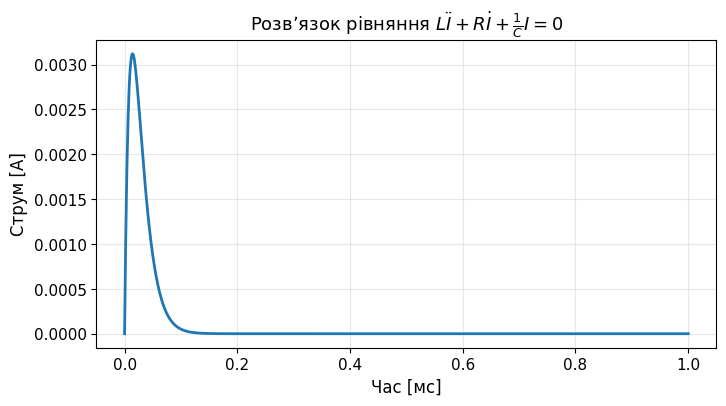

In [5]:
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt

# Крок 1: параметри кола
R = 2828  # опір, Ом
#R = 14140
L = 20e-3  # індуктивність, Гн
C = 10e-9  # ємність, Ф
V = 12     # напруга, В

t = smp.symbols('t')
I = smp.Function('I')(t)

# Крок 2: диференціальне рівняння
eq = smp.Eq(L * I.diff(t, 2) + R * I.diff(t) + (1/C) * I, 0)

# Крок 3: початкові умови i(0) = 0, di/dt(0) = V/L
ics = {
    I.subs(t, 0): 0,
    I.diff(t).subs(t, 0): V / L
}

# Крок 4: розв'язуємо диференціальне рівняння
sol = smp.dsolve(eq, I, ics=ics)

# Крок 5: перетворюємо символьний розв'язок на функцію Python
I_func = smp.lambdify(t, sol.rhs, 'numpy')

# Крок 6: моменти часу
time_values = np.linspace(0, 1e-3, 1000)  # інтервал 0…1 мс

# Крок 7: значення i(t)
current_values = I_func(time_values)

# Крок 8: графік
plt.plot(time_values * 1e3, current_values)  # час у мілісекундах
plt.title('Розв’язок рівняння $L\\ddot{I} + R\\dot{I} + \\frac{1}{C}I = 0$')
plt.xlabel('Час [мс]')
plt.ylabel('Струм [A]')
plt.grid(True)
plt.show()

Права частина розв'язку — сам вираз для струму $i(t)$:

In [6]:
sol.rhs

0.488273075262056*exp(-70700.0*t)*sin(1228.82057274606*t)

Ліва частина розв'язку — шукана функція $I(t)$:

In [7]:
sol.lhs

I(t)

Визначимо режим перехідного процесу, порівнявши $\left(\dfrac{R}{2L}\right)^2$ з $\dfrac{1}{LC}$ (див. випадки 1–4 вище):

In [8]:
if ((R/(2*L))**2) > 1/(L*C):
  print("Випадок 1: В цьому випадку корені рівнняння негативні і некомплексні")
elif ((R/(2*L))**2) == 1/(L*C):
  print("Випадок 2: В цьому випадку корені рівнняння комплексно-спряжені")
elif ((R/(2*L))**2) < 1/(L*C):
  print("Випадок 3: В цьому випадку корені рівнняння комплексно-спряжені")
elif R == 0:
  print("Випадок 4: В цьому випадку корені рівнняння негативні і некомплексні")
else:
  print("Помилка")

Випадок 3: В цьому випадку корені рівнняння комплексно-спряжені


Обчислимо корені характеристичного рівняння $p_{1,2} = -\dfrac{R}{2L} \pm \sqrt{\left(\dfrac{R}{2L}\right)^2 - \dfrac{1}{LC}}$:

In [9]:
D1, D2 = smp.symbols('D1 D2')

eq1 = -R/(2*L)+smp.sqrt( (R/(2*L))**2 - 1/(L*C) )-D1
eq2 = -R/(2*L)-smp.sqrt( (R/(2*L))**2 - 1/(L*C) )-D2

sol_2 = smp.solve([eq1, eq2], [D1,D2])

Корені характеристичного рівняння:

In [10]:
sol_2

{D1: -70700.0 + 1228.82057274445*I, D2: -70700.0 - 1228.82057274445*I}

Той самий струм знайдемо операторним методом: запишемо зображення $I(p)$, знайдемо корені знаменника і застосуємо формулу розкладу.

In [11]:
p = smp.symbols('p')
# Крок 2: зображення струму I(p) = (V/p) / Z(p)
eq = (V * C)/ (p**2 * L * C + p * R * C + 1) 
print(eq)

num,den = smp.fraction(eq)
print(num)
print(den)

# Крок 3: корені знаменника F2(p) та його похідна (формула розкладу)
sol_p = smp.solve([den], [p], dict=True)
print(sol_p)

den_diff = smp.diff(den, p)
print(den_diff)

I = smp.Function('I')(t) # струм у колі i(t)
I = ((num.subs(p,sol_p[0][p]))/(den_diff.subs(p,sol_p[0][p])))*smp.exp(sol_p[0][p]*t)+((num.subs(p,sol_p[1][p]))/(den_diff.subs(p,sol_p[1][p])))*smp.exp(sol_p[1][p]*t)
I_func = smp.lambdify(t, I, 'numpy')

# Крок 6: значення i(t) у кожен момент часу
current_values3 = np.array([I_func(ti) for ti in time_values])

1.2e-7/(2.0e-10*p**2 + 2.828e-5*p + 1)
1.20000000000000e-7
2.0e-10*p**2 + 2.828e-5*p + 1
[{p: -70700.0 - 1228.82057274445*I}, {p: -70700.0 + 1228.82057274445*I}]
4.0e-10*p + 2.828e-5


---
### Розрахунок паралельного включення RLC  <a class="anchor" id="RLC-parallel-commutation-calculation-classic"></a>

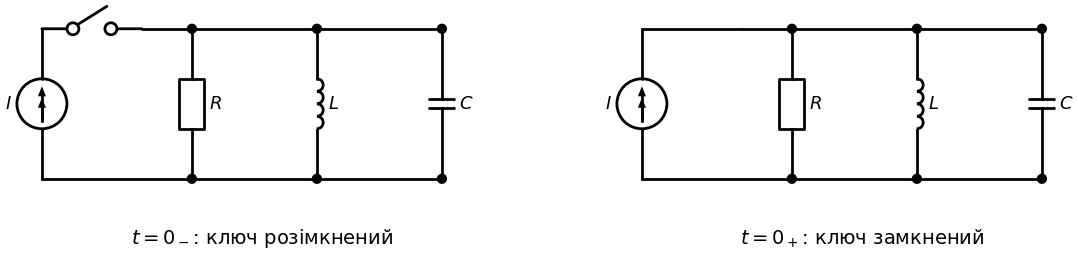

In [12]:
# Схема: паралельне RLC-коло з джерелом струму до (t = 0−) і після (t = 0+) комутації
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        for x0, closed, caption in [(0, False, '$t = 0_-$: ключ розімкнений'), (12, True, '$t = 0_+$: ключ замкнений')]:
            src = d.add(CurrentSource().at((x0, 0)).up().label('$I$'))
            d.add(elm.Line().right(2) if closed else elm.Switch().right(2))
            for k, (e, name) in enumerate([(elm.Resistor, '$R$'), (elm.Inductor, '$L$'), (elm.Capacitor, '$C$')]):
                x = x0 + 3 + 2.5*k
                if k:
                    d.add(elm.Line().at((x - 2.5, 3)).right(2.5))
                else:
                    d.add(elm.Line().at((x0 + 2, 3)).right(1))
                d.add(elm.Dot().at((x, 3)))
                d.add(e().at((x, 3)).down().label(name, loc='bottom'))
                d.add(elm.Dot().at((x, 0)))
            d.add(elm.Line().at((x0 + 8, 0)).left().tox(src.start))
            d.add(elm.Label().at((x0 + 4.5, -1.1)).label(caption, fontsize=14))

Запишемо диференційне рівняння для опису схеми в момент $t(0_+)$ після комутації:

$$i_{in}(t) =  i_{R}(t) + i_{L}(t) + i_{C}(t)$$

$$i_{in}(t) =  \cfrac{v}{R}  + \cfrac{1}{L} \int v dt + C \cfrac{dv}{dt}$$

Візьмемо похідну:

$$ C \cfrac{d^2v(t)}{dt^2} + \cfrac{1}{R}\cfrac{dv(t)}{dt} + \cfrac{1}{L} v(t)  = 0 $$

Поділимо на $C$ і виконаємо заміну  $D$:

$$  D^2 + \cfrac{1}{RC} D + \cfrac{1}{LC}  = 0 $$

$$ D_{1} = -\cfrac{1}{2RC} + \sqrt{  (\cfrac{1}{2RC})^2 - \cfrac{1}{LC} }$$

$$ D_{2} = -\cfrac{1}{2RC} - \sqrt{  (\cfrac{1}{2RC})^2 - \cfrac{1}{LC} }$$

Введемо заміни:

$$ \alpha = \cfrac{1}{2RC}$$

$$ \beta  = \sqrt{  (\cfrac{1}{2RC})^2 - \cfrac{1}{LC} }$$

$$ D_{1} = -\alpha + \beta$$

$$ D_{2} = -\alpha - \beta$$

---
#### Випадок 1: 

$$ (\cfrac{1}{2RC})^2 >  \cfrac{1}{LC} $$

В цьому випадку корені рівнняння негативні і некомплексні

$$ v_{c}(t) = C_{1} \cdot e^{-D_{1}t} + C_{2} \cdot e^{-D_{2}t}$$

Overdamped response

$$ (\cfrac{1}{2RC})^2 >  \cfrac{1}{LC} $$

---
#### Випадок 2: 

$$(\cfrac{1}{2RC})^2 =   \cfrac{1}{LC} $$

В цьому випадку корені рівнняння негативні, некомплексні і однакові

$$ D_{1} = D_{2} = - \alpha$$

$ v_{c}(t) = (C_{1} + C_{2}t) \cdot e^{-\alpha t}  $

Critically damped response

$$(\cfrac{1}{2RC})^2 =   \cfrac{1}{LC} $$

---
#### Випадок 3: 

$$ (\cfrac{1}{2RC})^2 <   \cfrac{1}{LC} $$

В цьому випадку корені рівнняння комплексно-спряжені

$$ D_{1} = - \alpha + j\beta $$
$$ D_{2} = - \alpha - j\beta $$

$$ v_{c}(t) = e^{-\alpha t} \cdot ( C_{1} cos( \beta t) +C_{2} sin( \beta t)) $$

Under damped response

$$ (\cfrac{1}{2RC})^2 <   \cfrac{1}{LC} $$

---
#### Випадок 4: 

$$ R = \infty $$

В цьому випадку корені рівнняння комплексні

$$ D_{1} = j \sqrt{\frac{1}{LC}} = j \omega $$
$$ D_{2} = - j \omega $$

$$ v_{c}(t) =   C_{1} cos( \omega t) +C_{2} sin( \omega t)  $$

---

In [13]:
def g(R_sb, L_sb, C_sb):
    # схема
    circuit = Circuit('RLC series connection')
    source = circuit.PulseCurrentSource('input', 1, circuit.gnd,
                                        initial_value=0@u_A, pulsed_value=10@u_A,
                                        pulse_width=100@u_ms, period=200@u_ms)
    # елементи кола
    circuit.R(1, 1, circuit.gnd, R_sb@u_Ω)
    circuit.L(1, 1, circuit.gnd, L_sb@u_mH)
    circuit.C(1, 1, circuit.gnd, C_sb@u_uF)

    # моделювання перехідного процесу
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    steptime = 1@u_us
    finaltime = 200@u_ms
    analysis = simulator.transient(step_time=steptime, end_time=finaltime)

    # графіки результатів
    figure, axe = plt.subplots(figsize=(10, 6))
    plt.title('Перехідний процес послідовно включених RLC')
    plt.xlabel('Час, [с]')
    plt.ylabel('Напруга, [В]')

    plot(analysis['1'], axis=axe)

    plt.grid()
    plt.legend(('Напруга на конденсаторі','Вхідний сигнал' ), loc='best')
    cursor = Cursor(axe, useblit=True, color='red', linewidth=1)
    plt.tight_layout()
    plt.show()

w = interactive(g, 
                R_sb=widgets.IntSlider(min=0, max=1000, step=1, value=40, description = r'$R_{1}, [\Omega]$'), 
                L_sb=widgets.IntSlider(min=1, max=1000, step=1, value=300, description ='$L_{1}, [uH]$'), 
                C_sb=widgets.IntSlider(min=1, max=100, step=1, value=10, description = '$C_{1},[mF]$'))
display(w)

interactive(children=(IntSlider(value=40, description='$R_{1}, [\\Omega]$', max=1000), IntSlider(value=300, de…

**Паралельне RLC-коло.** SymPy (`dsolve`) розв'язує рівняння другого порядку для напруги $v(t)$ з початковими умовами: конденсатор заряджений до $V_{in}$, струм котушки дорівнює нулю. Будуємо графік $v(t)$.

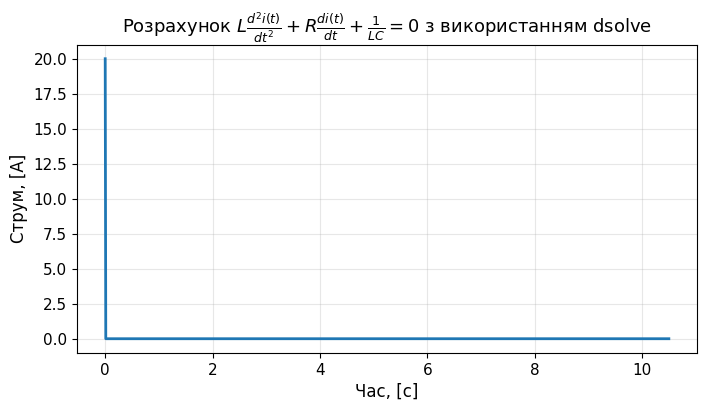

In [14]:
# Крок 1: параметри кола
R = 0.01  # опір, Ом
L = 1  # індуктивність, Гн
C = 0.05  # ємність, Ф
Vin = 20   # постійна напруга джерела, В

t = smp.symbols('t')  # час
V = smp.Function('V')(t)  # напруга на контурі v(t)

# Крок 2: диференціальне рівняння
eq = C * V.diff(t, 2) + 1/R * V.diff(t) + 1/L * V
# Initial conditions: заряджений конденсатор V(0)=Vin, i_L(0)=0 -> C*V'(0) = -Vin/R
ics = {V.subs(t, 0): Vin, smp.diff(V, t).subs(t, 0): -Vin/(R*C)}

# Крок 3: розв'язуємо диференціальне рівняння
sol = smp.dsolve(eq, V, ics=ics)


# Крок 4: перетворюємо символьний розв'язок на функцію Python
V_func = smp.lambdify(t, sol.rhs, 'numpy')

# Крок 5: моменти часу
time_values = np.linspace(0, 10.5, 1000)  # інтервал часу, с

# Крок 6: v(t) у кожен момент часу
current_values = np.array([V_func(ti) for ti in time_values])

# Крок 7: графік
plt.plot(time_values, current_values)
plt.title('Розрахунок $ L\\frac{d^{2}i(t)}{dt^{2}} + R\\frac{di(t)}{dt} + \\frac{1}{LC} = 0 $ з використанням dsolve')
plt.xlabel('Час, [c]')
plt.ylabel('Струм, [A]')
plt.grid(True)
plt.show()


Отриманий вираз для напруги $v(t)$:

In [15]:
sol.rhs

20.0001000015*exp(-1999.98999995*t) - 0.00010000150002*exp(-0.0100000500005*t)

Значення напруги в момент $t = 2$ с — перехідний процес практично завершився:

In [16]:
V_func(2)


np.float64(-9.802132784605816e-05)

$$ C \cfrac{d^2v(t)}{dt^2} + \cfrac{1}{R}\cfrac{dv(t)}{dt} + \cfrac{1}{L} v(t)  = 0 $$


---
### ⚡ Практичне застосування: Перехідні процеси 2-го порядку (RLC)

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Три режими перехідного процесу в послідовному RLC:**

| Режим | Умова | Характер u_C(t) | Де використовується |
|-------|-------|----------------|--------------------|
| **Аперіодичний** | $R > 2\sqrt{L/C}$ | Монотонне наростання | Схеми живлення без перерегулювання |
| **Критичний** | $R = 2\sqrt{L/C}$ | Монотонне, мінімальний час | Швидкодіючі позиціонери |
| **Коливний (недогасаючий)** | $R < 2\sqrt{L/C}$ | Затухаючі коливання | LC-генератори, резонансні контури |

**Добротність:**
$$Q = \frac{1}{R}\sqrt{\frac{L}{C}} = \frac{\omega_0}{2\delta}$$
де $\delta = R/(2L)$ — декремент затухання. Чим більше $Q$, тим повільніше затухає процес.

> **Радіопрактика:** Резонансний контур радіоприймача — це RLC-ланцюг у коливному режимі. $Q = 50\ldots200$ забезпечує вибірковість каналів.

</div>

---
### ✅ Питання для самоперевірки: Перехідні процеси 2-го порядку

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> При яких умовах виникає аперіодичний, критичний і коливний режими?</summary>

> **Відповідь:** Дискримінант характеристичного рівняння $p^2 + 2\delta p + \omega_0^2 = 0$:
> - $\delta^2 > \omega_0^2$ ($R > 2\sqrt{L/C}$) — два дійсних кореня, аперіодичний режим.
> - $\delta^2 = \omega_0^2$ — кратний корінь, критичний режим.
> - $\delta^2 < \omega_0^2$ — комплексні корені, коливний режим.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Яка фізична роль декременту затухання delta?</summary>

> **Відповідь:** $\delta = R/(2L)$ — показник швидкості спаду огинаючої коливань: $e^{-\delta t}$. За час $\tau = 1/\delta$ амплітуда зменшується в $e$ разів.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Що таке часткова частота і яка відмінність від резонансної?</summary>

> **Відповідь:** Резонансна (власна): $\omega_0 = 1/\sqrt{LC}$. Частота коливань при перехідному процесі: $\omega_d = \sqrt{\omega_0^2 - \delta^2} < \omega_0$. При малому загасанні $\omega_d \approx \omega_0$.

</details>

---
### 📝 Задачі для самостійного розв'язання: Перехідні процеси другого порядку


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Послідовний $RLC$-контур: $L = 10$ мГн, $C = 1$ мкФ, $R = 20$ Ом, вмикається на постійну напругу. Визначте критичний опір, характер процесу, частоту вільних коливань, сталу згасання та перерегулювання напруги на конденсаторі.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $R_{кр} = 2\sqrt{L/C} = 200$ Ом $> R$ — коливальний режим. $\alpha = R/2L = 1000$ с⁻¹ ($\tau = 1$ мс); $\omega_0 = 10^4$ рад/с; $\omega_в = \sqrt{\omega_0^2 - \alpha^2} \approx 9950$ рад/с ($f_в \approx 1{,}58$ кГц); $Q = \rho/R = 5$. Перерегулювання $e^{-\alpha\pi/\omega_в} \approx 0{,}73$, тобто $u_C$ сягає $\approx 1{,}73E$.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** У тому самому контурі $R = 300$ Ом. Знайдіть корені характеристичного рівняння і вкажіть режим.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $R > R_{кр}$ — аперіодичний режим. $p_{1,2} = -\alpha \pm \sqrt{\alpha^2 - \omega_0^2}$, $\alpha = 15000$ с⁻¹: $p_1 \approx -3820$ с⁻¹, $p_2 \approx -26180$ с⁻¹.

</details>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 11. Операторний метод розрахунку перехідних процесів](Тема_11_Операторний_метод.ipynb) &nbsp;|&nbsp; [Тема 13. Довга лінія](Тема_13_Довга_лінія.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
